### Histórico TRM

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from market_col.dir_set import project_root_nb
from market_col.figures import static_plot
from market_col.plotly import plotly_oneplot

In [3]:
PROJECT_DIR = project_root_nb()

In [4]:
url = "https://www.datos.gov.co/resource/32sa-8pi3.json"
newTRM = pd.read_json(url)

In [5]:
newTRM["vigenciadesde"] = pd.to_datetime(newTRM["vigenciadesde"])
newTRM["vigenciahasta"] = pd.to_datetime(newTRM["vigenciahasta"])
newTRM = newTRM[["vigenciadesde", "vigenciahasta", "valor"]]

In [6]:
# Crear una lista de fechas para cada fila
newTRM["fecha"] = newTRM.apply(
    lambda x: pd.date_range(x["vigenciadesde"], x["vigenciahasta"], freq="D"),
    axis=1
)

# Expandir las listas
newTRM = newTRM.explode("fecha")

# Conservar únicamente lo necesario
newTRM = (
    newTRM[["fecha", "valor"]]
    .reset_index(drop=True)
)

print(newTRM.head())

       fecha    valor
0 2026-08-21  3062.96
1 2026-08-20  3053.48
2 2026-08-19  3098.79
3 2026-08-15  3128.65
4 2026-08-16  3128.65


In [7]:
newTRM = newTRM.sort_values(by='fecha', ascending=True).reset_index(drop=True)

In [8]:
oldTRM = pd.read_csv(f"{PROJECT_DIR}/Data/TRM/TRM.csv", parse_dates=["fecha"])

In [9]:
fullTRM = pd.concat([oldTRM, newTRM]).drop_duplicates(subset='fecha', keep='last').reset_index(drop=True)

In [10]:
fullTRM.to_csv(f"{PROJECT_DIR}/Data/TRM/newTRM.csv", index=False)
fullTRM['fecha'] = pd.to_datetime(fullTRM['fecha'])

In [11]:
fullTRM

,fecha,valor
0,2022-04-30,3966.27
1,2022-05-01,3966.27
2,2022-05-02,3966.27
3,2022-05-03,4004.07
4,2022-05-04,4016.34
...,...,...
1570,2026-08-17,3128.65
1571,2026-08-18,3128.65
1572,2026-08-19,3098.79
1573,2026-08-20,3053.48


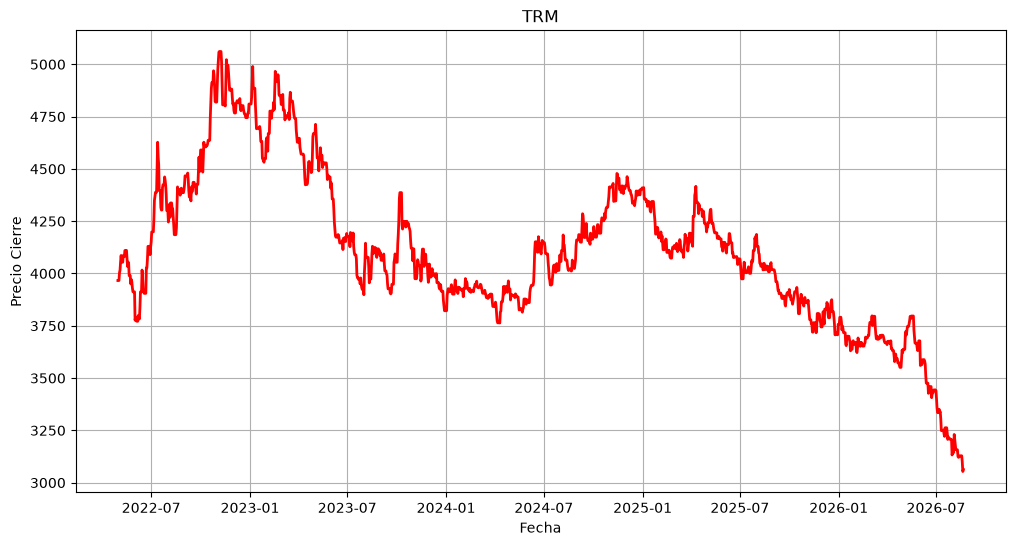

In [12]:
titulo = "TRM"
plt.figure(figsize=(12,6))
plt.plot(fullTRM["fecha"], fullTRM["valor"], color = "red", linewidth=2)
plt.title(titulo)
plt.xlabel("Fecha")
plt.ylabel("Precio Cierre")
plt.grid(True)
plt.show()

In [13]:
plotly_oneplot(data = fullTRM, x_col="fecha", y_col="valor", plot_title="TRM", color_in="red")

In [14]:

import plotly.graph_objects as go
import nbformat as nbf
def plotly_oneplot_prueba(data, x_col, y_col, plot_title, color_in, date_marker = None):
    """
    Create an interactive plot using Plotly.

    Parameters:
    data (pd.DataFrame): The data to plot.
    x_col (str): The column name for the x-axis.
    y_col (str): The column name for the y-axis.
    title (str): The title of the plot.
    x_title (str): The title of the x-axis.
    y_title (str): The title of the y-axis.

    Returns:
    plotly.graph_objects.Figure: The interactive plot.
    """

    data["retorno"] = data[y_col].pct_change() * 100  # Retorno porcentual
    #data["base100"] = (data[y_col] / data[y_col].iloc[0]) * 100

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=data[x_col], y=data[y_col], mode='lines', name=y_col, line=dict(color=color_in, dash = "solid")))
 
    # Serie de retornos

    fig.add_trace(go.Bar(x=data[x_col], y=data["retorno"],name="Retorno (%)", yaxis="y2", marker_color = "rgba(128, 128, 128, 0.4)"))

    # Serie de base100
    #fig.add_trace(go.Scatter(x=data[x_col], y=data["base100"],name="Base 100", yaxis="y3", line=dict(color=color_in, dash="solid")))

    if date_marker is not None:
        fig.add_vline(
        x= date_marker,
        line_dash="dash",
        line_color="red",
        line_width=1
        )


    fig.update_layout(
        title= plot_title,
        xaxis_title = "Fecha",
        yaxis_title = "Valor",
        template="plotly_white",
        hovermode="x unified",
        #yaxis=dict(title="base100", overlaying="y", side="left", zeroline=True),
        yaxis=dict(title="Precio"),
        yaxis2=dict(title="Retorno (%)", overlaying="y", side="right", zeroline=True)
    )

    fig.update_layout(
        xaxis=dict(
            rangeslider=dict(
                visible=True
            )
        )
    )

    fig.update_layout(
        xaxis=dict(
            rangeselector=dict(
                buttons=[
                    dict(count=1, label="1M", step="month", stepmode="backward"),
                    dict(count=6, label="6M", step="month", stepmode="backward"),
                    dict(count=1, label="YTD", step="year", stepmode="todate"),
                    dict(count=1, label="1A", step="year", stepmode="backward"),
                    dict(step="all", label="Todo")
                ]
            ),
            rangeslider=dict(visible=True),
            type="date"
        )
    )

    fig.update_yaxes(
    fixedrange=False,
    autorange=True
    )

    fig.update_yaxes(
        showgrid=False
    )

    return fig


In [15]:
plotly_oneplot_prueba(data = fullTRM, x_col="fecha", y_col="valor", plot_title="TRM", color_in="red")